# Entity Embedding Estimation



This notebook runs the experiment in our work for the GDA project, where we estimate an unseen embedding during training using the equation:

$$ \mathbf{\hat{e}_o} = \sum_{(s,p) \in S_o'} \mathbf{r}_p * \mathbf{e}_s$$

The notebook begins by creating data disconnected from a selected point. This data can be saved in a `.pkl` object to train a model with it.

After, we explore a particular case, and after run the entire inference sequences presented in the report.

In [24]:
import pickle as pkl
import numpy as np
import matplotlib.pyplot as plt
import sys
from numpy.fft import fft, ifft
from tqdm import tqdm
import logging
logging.getLogger().setLevel(logging.CRITICAL)
sys.path.append('..')

from skge.hole import HolE, ccorr
import skge.actfun as af
from kg.base import ranking_scores
from kg.run_hole import HolEEval

# Step 1: Initialize Data

We split the data into the partition $\mathcal{D} = \mathcal{D'} \cup \mathcal{D}_o$, such that $\mathcal{D}_o$ is the subgraph of all the triples involed with $o$.

In [2]:
# Open the initial wn18 data.
with open('../data/wn18.bin', 'rb') as f:
    data = pkl.load(f)
data.keys()

dict_keys(['relations', 'train_subs', 'entities', 'test_subs', 'valid_subs'])

In [3]:
# Data exploration
data['train_subs'][0][0]
unique_relations_full = set(rel for split in ['train_subs', 'valid_subs', 'test_subs'] for _, _, rel in data[split])
unique_entities_full = set(ent for split in ['train_subs', 'valid_subs', 'test_subs'] for triple in data[split] for ent in triple[:-1])

print(f"Number of unique relations in full data: {len(unique_relations_full)}")
print(f"Number of unique entities in full data: {len(unique_entities_full)}")

Number of unique relations in full data: 18
Number of unique entities in full data: 40943


In [ ]:
# Separate D_o and D_prime
selected_entity_idx = 1004  # Select an index for 'o' entity. See Appendix section for finding a good index.
# ------------------------------------------------------

D_o = {}
D_prime = {}
for split in ['train_subs', 'valid_subs', 'test_subs']:
    D_o[split] = []
    D_prime[split] = []
    for triplet in data[split]:
        if triplet[0] == selected_entity_idx or triplet[1] == selected_entity_idx:
            D_o[split].append(triplet)
        else:
            D_prime[split].append(triplet)

print("Number of triplets with the selected entity:", sum(len(v) for v in D_o.values()))
unique_relations_filtered = {rel for split in D_prime.values() for _, _, rel in split}
unique_entities_filtered = {ent for split in D_prime.values() for triple in split for ent in triple[:-1]}
print("Selected entity index:", selected_entity_idx)
assert unique_relations_filtered == unique_relations_full, "Relations do not match after filtering! Try another index."
assert unique_entities_filtered == unique_entities_full - set([selected_entity_idx]), "Entities match after filtering! Try another index."
print("Amount of unique relations (filtered vs full):", len(unique_relations_filtered), len(unique_relations_full))
print("Amount of unique entities (filtered vs full):", len(unique_entities_filtered), len(unique_entities_full))

Number of triplets with the selected entity: 150
Selected entity index: 1004
Amount of unique relations (filtered vs full): 18 18
Amount of unique entities (filtered vs full): 40942 40943


In [5]:
# data_new = D_prime
# data_new['entities'] = [ent for ent in data['entities'] if ent != selected_entity_idx]
# data_new['relations'] = data['relations']
# with open(f'../data/wn18_entity_removed_{selected_entity_idx}.bin', 'wb') as f:
#     pkl.dump(data_new, f)

At this point, if you are recreating the experiment, you would want to do retraining using this data.
You can use [`run_hole_wn18_entity_removed.sh`](../run_hole_wn18_entity_removed.sh) for this task.

In [13]:
PATH_TO_MODEL_ON_D_PRIME = '../results/hole_wn18_entity_removed/20251206_223703/best_val.pkl'  # Update with your path to the model!

# 2: Embedding estimation

In [14]:
model = HolE.load(PATH_TO_MODEL_ON_D_PRIME)['model']
model.E.shape, model.R.shape

((40943, 150), (18, 150))

In [15]:
def estimate_entity_embedding(model, doubles_for_inference):
    e = np.zeros(model.E.shape[1])
    for entity, relation, _ in doubles_for_inference:
        e += ifft(fft(model.E[entity]) * fft(model.R[relation])).real
    return e

So = [
    (es, rel, split_type) for split_type, split in D_o.items() for es, eo, rel in split if eo == selected_entity_idx
]
print("Amount of triples related to the eo:", len(So))

Amount of triples related to the eo: 75


In [11]:
index_to_infer = len(So) - 1
So_to_estimate = So[index_to_infer]
So_estimation_subset = So[:index_to_infer] + So[index_to_infer+1:]

e_ = estimate_entity_embedding(model, So_estimation_subset)
ent, rel, split_type = So[index_to_infer]
proba = af.Sigmoid.f(model.R[rel].T @ ccorr(model.E[ent], e_))

print("Split:", split_type)
print("Estimated entity index:", ent)
print("Relation index:", rel)
print("Predicted score for triple (ent, rel, estimated_entity):", proba)

Split: test_subs
Estimated entity index: 33885
Relation index: 15
Predicted score for triple (ent, rel, estimated_entity): 0.9999997740399369


# Step 3: Probability inference and MRR Score

## Probabilities

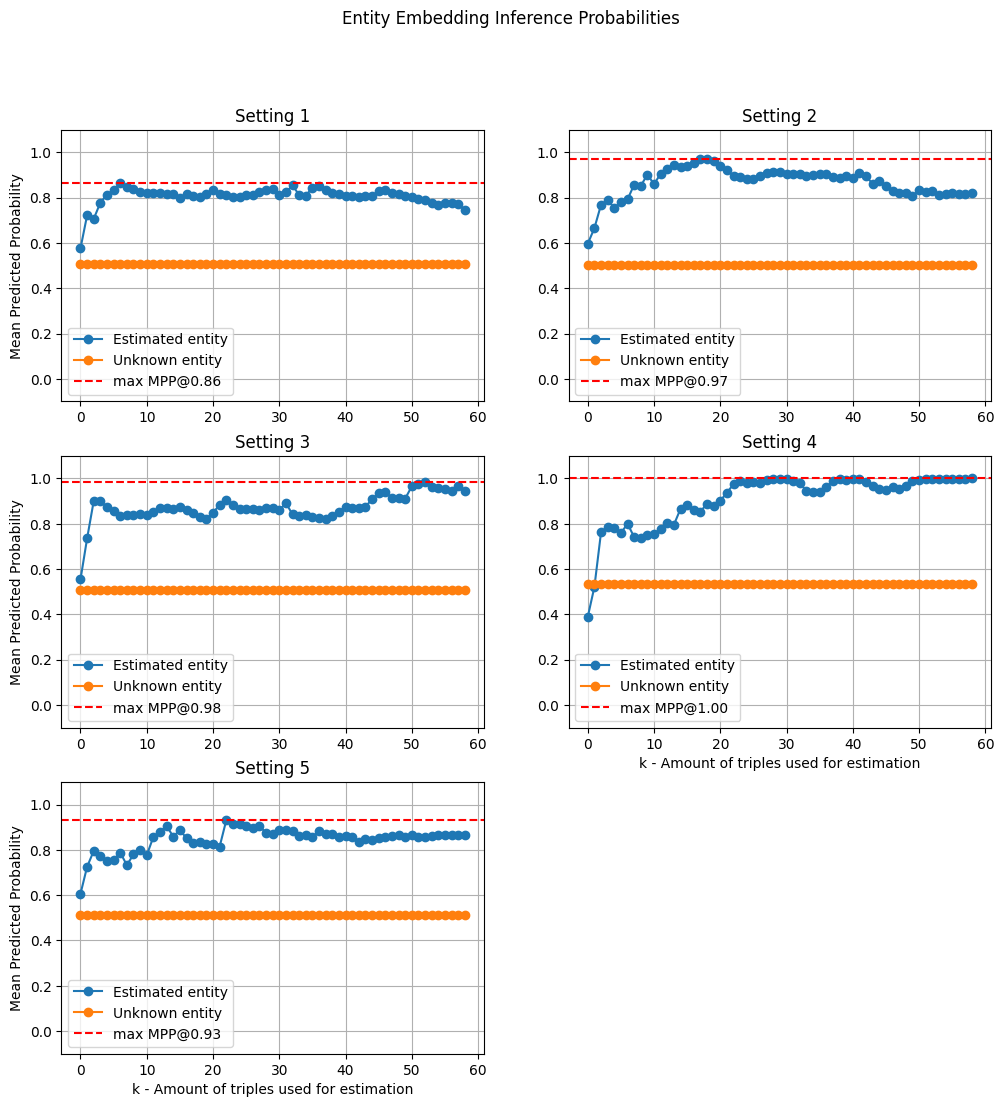

In [27]:
model = HolE.load(PATH_TO_MODEL_ON_D_PRIME)['model']

# Inference the entity embedding probabilities over So'', given eo' estimated from So'
inference_setting_size = 15
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

for i, (ax, setting_idx) in enumerate(zip(axs.flatten(), range(0, len(So), inference_setting_size))):
    So_to_infer = So[setting_idx:setting_idx+inference_setting_size]  # Equivalent to S_o''
    So_for_estimation = So[:setting_idx] + So[setting_idx+inference_setting_size:]  # Equivalent to S_o'

    #baseline probabilities
    baseline_proba_mean = 0
    for es, rel, split_type in So_to_infer:
        proba = af.Sigmoid.f(model.R[rel].T @ ccorr(model.E[es], model.E[selected_entity_idx]))
        baseline_proba_mean += proba
    baseline_proba_mean /= len(So_to_infer)
    baseline_probas = baseline_proba_mean * np.ones(len(So_for_estimation)-1)

    probas = []
    for idx in range(1,len(So_for_estimation)):
        So_estimation_subset = So_for_estimation[:idx]

        # infer entity embedding and predict
        eo_ = estimate_entity_embedding(model, So_estimation_subset)
        proba_mean = 0
        for es, rel, split_type in So_to_infer:
            proba = af.Sigmoid.f(model.R[rel].T @ ccorr(model.E[es], eo_))
            proba_mean += proba
        proba_mean /= len(So_to_infer)
        probas.append(proba_mean.copy())

    ax.plot(probas, marker='o', label='Estimated entity')
    ax.plot(baseline_probas, marker='o', label='Unknown entity')
    max_proba = np.max(probas)
    ax.axhline(y=max_proba, color='r', linestyle='--', label=f'max MPP@{max_proba:.2f}')
    ax.grid()
    ax.set_ylim(-0.1,1.1)
    ax.legend()
    ax.set_title(f'Setting {i+1}')

probas = []
for idx in range(1,len(So)):
    es, rel, split_type = So[idx]
    proba_mean = 0
    for es, rel, split_type in So_to_infer:
        proba = af.Sigmoid.f(model.R[rel].T @ ccorr(model.E[es], eo_))
        proba_mean += proba

        proba_mean /= len(So_to_infer)
    proba = af.Sigmoid.f(model.R[rel].T @ ccorr(model.E[es], model.E[selected_entity_idx]))
    probas.append(proba.copy())

for i in range(3):
    axs[i,0].set_ylabel('Mean Predicted Probability')
axs[2,0].set_xlabel('k - Amount of triples used for estimation')
axs[1,1].set_xlabel('k - Amount of triples used for estimation')

fig.delaxes(axs[2,1])
plt.suptitle('Entity Embedding Inference Probabilities')
plt.legend()
plt.show()

## Rank

In [22]:
# Get the score ranks for the last setting case
model = HolE.load(PATH_TO_MODEL_ON_D_PRIME)['model']
selected_idx_triples = [
    (es, selected_entity_idx, rel) for es, rel, _ in So_to_infer
]
true_triples = data['test_subs'] + data['train_subs'] + data['valid_subs']  # triplets_without_entity['test_subs']

eo_bad = model.E[selected_entity_idx]  # Bad embedding (random)
evaluator = HolEEval(selected_idx_triples, true_triples )
model.E[selected_entity_idx] = eo_bad
pos_v, fpos_v = evaluator.positions(model)
scores_ori = ranking_scores(pos_v, fpos_v, 0, 'Test')
print("Scores before adding embedding estimation:", scores_ori)

model_extended = model
model_extended.E[selected_entity_idx] = eo_
evaluator = HolEEval(selected_idx_triples, true_triples )
pos_v, fpos_v = evaluator.positions(model_extended)
scores_new = ranking_scores(pos_v, fpos_v, 0, 'Test')
print("Scores after adding embedding estimation:", scores_new)

Scores before adding embedding estimation: 0.00028650714612428013
Scores after adding embedding estimation: 0.4184446718033839


Base case
Setting 1 - Calculating baseline score...


Setting 1 - Calculating estimated entity scores: 100%|██████████| 59/59 [00:27<00:00,  2.11it/s]


Setting 2 - Calculating baseline score...


Setting 2 - Calculating estimated entity scores: 100%|██████████| 59/59 [00:34<00:00,  1.69it/s]


Setting 3 - Calculating baseline score...


Setting 3 - Calculating estimated entity scores: 100%|██████████| 59/59 [00:30<00:00,  1.96it/s]


Setting 4 - Calculating baseline score...


Setting 4 - Calculating estimated entity scores: 100%|██████████| 59/59 [00:29<00:00,  2.01it/s]


Setting 5 - Calculating baseline score...


Setting 5 - Calculating estimated entity scores: 100%|██████████| 59/59 [00:29<00:00,  2.00it/s]


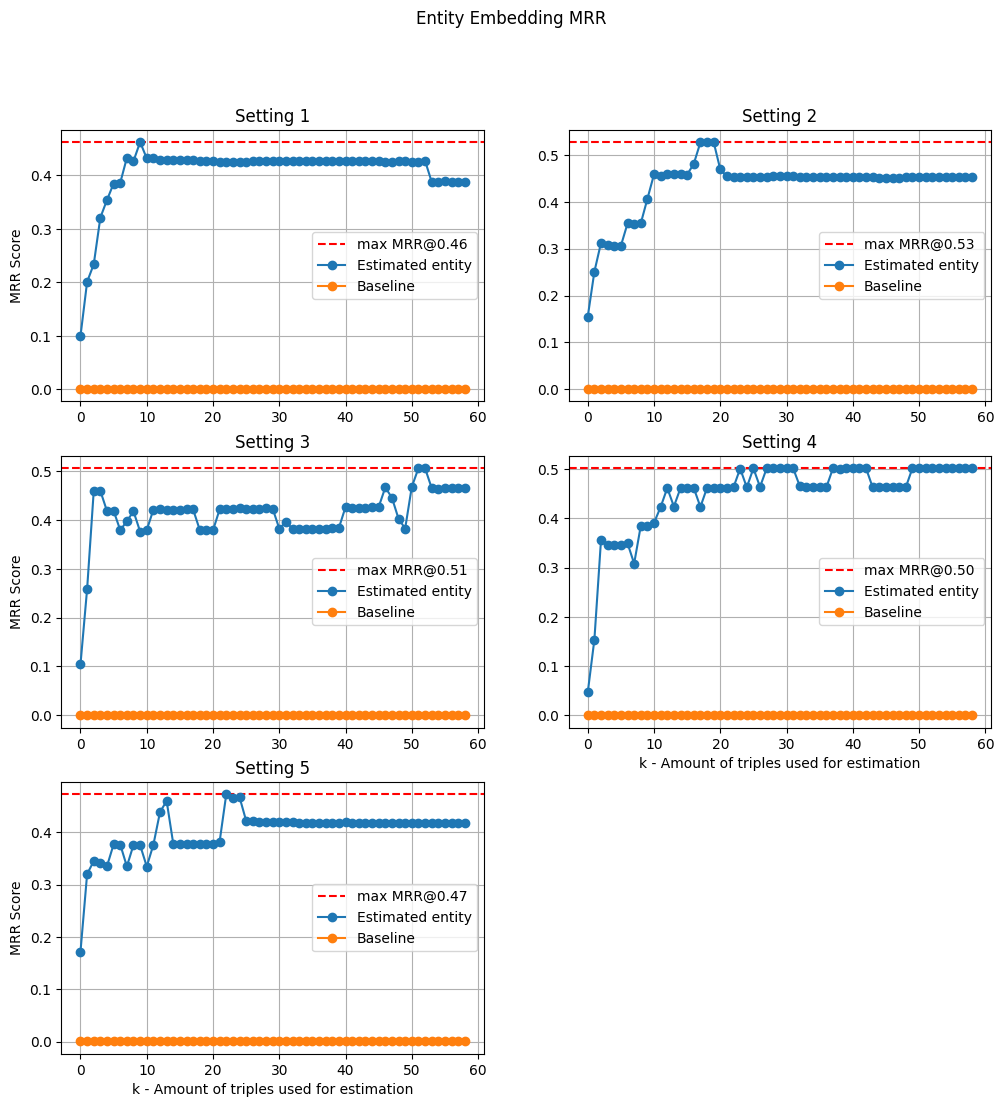

In [28]:
# MRR scores over all settings
scores = []
inference_setting_size = 15
fig, axs = plt.subplots(3, 2, figsize=(12, 12))

model = HolE.load(PATH_TO_MODEL_ON_D_PRIME)['model']
eo_bad = model.E[selected_entity_idx].copy()  # Bad embedding (random)
model_extended = model

print("Base case")
true_triples = data['test_subs'] + data['train_subs'] + data['valid_subs']

for i, (ax, setting_idx) in enumerate(zip(axs.flatten(), range(0, len(So), inference_setting_size))):
    So_to_infer = So[setting_idx:setting_idx+inference_setting_size]
    So_for_estimation = So[:setting_idx] + So[setting_idx+inference_setting_size:]

    selected_idx_triples = [
        (es, selected_entity_idx, rel) for es, rel, _ in So_to_infer
    ]

    model.E[selected_entity_idx] = eo_bad
    print(f"Setting {i+1} - Calculating baseline score...")
    evaluator = HolEEval(selected_idx_triples, true_triples )
    pos_v, fpos_v = evaluator.positions(model)
    baseline_scores_i = ranking_scores(pos_v, fpos_v, 0, 'Test')
    baseline_scores = baseline_scores_i.copy() * np.ones(len(So_for_estimation)-1)

    scores = []
    for idx in tqdm(range(1,len(So_for_estimation)), desc=f"Setting {i+1} - Calculating estimated entity scores"):
        So_estimation_subset = So_for_estimation[:idx]

        eo_ = estimate_entity_embedding(model, So_estimation_subset)
        model_extended.E[selected_entity_idx] = eo_
        evaluator = HolEEval(selected_idx_triples, true_triples )
        pos_v, fpos_v = evaluator.positions(model_extended)
        scores_i = ranking_scores(pos_v, fpos_v, 0, 'Test')
        scores.append(scores_i.copy())


    max_mrr = np.max(scores)
    ax.axhline(y=max_mrr, color='r', linestyle='--', label=f'max MRR@{max_mrr:.2f}')
    ax.plot(scores, marker='o', label='Estimated entity')
    ax.plot(baseline_scores, marker='o', label='Baseline')
    ax.grid()
    ax.legend()
    ax.set_title(f'Setting {i+1}')

for i in range(3):
    axs[i,0].set_ylabel('MRR Score')
axs[2,0].set_xlabel('k - Amount of triples used for estimation')
axs[1,1].set_xlabel('k - Amount of triples used for estimation')

fig.delaxes(axs[2,1])
plt.suptitle('Entity Embedding MRR')
plt.legend()
plt.show()

# Appendix: Search for an appropriate $o$

We fixed 'o' to 1004 in out experiments, but in truth we have to look for two things:
- We would like 'o' to have a large number of triples related to it, so that we have margin for generating statistically sufficient $\mathcal{D}'$, $S_o'$ and $S_o''$.
- It's important that we don't have a mismatch in the relations available in $\mathcal{D'}$ and $\mathcal{D}_o$.

In [ ]:
# Select an index with many connections to the rest of the graph
while True:
    try:
        selected_entity_idx = np.random.randint(len(unique_entities_full)) # Select an index # 1004

        triplets_with_entity = {}
        triplets_without_entity = {}
        for split in ['train_subs', 'valid_subs', 'test_subs']:
            triplets_with_entity[split] = []
            triplets_without_entity[split] = []
            for triplet in data[split]:
                if triplet[0] == selected_entity_idx or triplet[1] == selected_entity_idx:
                    triplets_with_entity[split].append(triplet)
                else:
                    triplets_without_entity[split].append(triplet)

        unique_relations_filtered = {rel for split in triplets_without_entity.values() for _, _, rel in split}
        unique_entities_filtered = {ent for split in triplets_without_entity.values() for triple in split for ent in triple[:-1]}

        assert unique_relations_filtered == unique_relations_full, "Relations do not match after filtering! Try another index."
        assert unique_entities_filtered == unique_entities_full - set([selected_entity_idx]), "Entities match after filtering! Try another index."
        So = [
            (es, rel, split_type) for split_type, split in triplets_with_entity.items() for es, eo, rel in split if eo == selected_entity_idx
        ]

        if len(So) > 10:
            print("Selected entity index:", selected_entity_idx)
            print("Amount of triples related to the empty:", len(So))
            print("Triples in train:", sum(1 for s in So if s[2]=='train_subs'), " valid:", sum(1 for s in So if s[2]=='valid_subs'), " test:", sum(1 for s in So if s[2]=='test_subs'))
            if len(So) > 50:
                break
    except AssertionError as e:
        continue

Selected entity index: 908
Amount of triples related to the empty: 41
Triples in train: 40  valid: 0  test: 1
Selected entity index: 4316
Amount of triples related to the empty: 12
Triples in train: 11  valid: 1  test: 0
Selected entity index: 6259
Amount of triples related to the empty: 12
Triples in train: 11  valid: 0  test: 1
Selected entity index: 798
Amount of triples related to the empty: 41
Triples in train: 39  valid: 1  test: 1
Selected entity index: 4220
Amount of triples related to the empty: 15
Triples in train: 14  valid: 0  test: 1
Selected entity index: 25468
Amount of triples related to the empty: 11
Triples in train: 10  valid: 1  test: 0
Selected entity index: 3503
Amount of triples related to the empty: 20
Triples in train: 19  valid: 0  test: 1
Selected entity index: 20686
Amount of triples related to the empty: 17
Triples in train: 17  valid: 0  test: 0
Selected entity index: 11363
Amount of triples related to the empty: 22
Triples in train: 20  valid: 2  test: 0


1556